In [1]:
import pandas as pd
import numpy as np
import re 
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer 
import transformers
from transformers import pipeline


In [4]:
data = pd.read_csv('book_reviews_sample.csv')
data.head()


,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [5]:
data['reviewText'][0]


'Clean and funny. A bit busy with all the different plots going on. But overall a good read. Bye now.'

In [6]:
data['reviewText_clean'] =data['reviewText'].str.lower()
data['reviewText_clean'] =data['reviewText'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', str(x).lower().strip()))

In [7]:
data.head()

,index,reviewText,rating,reviewText_clean
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


In [8]:
vader_sentiment = SentimentIntensityAnalyzer()


In [10]:
data['vader_sentiment_sccore']=data['reviewText_clean'].apply(lambda x: vader_sentiment.polarity_scores(x)['compound'])

In [11]:
data.head()

,index,reviewText,rating,reviewText_clean,vader_sentiment_sccore
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767


In [12]:
bins=[-1,-0.1,0.1,1]
names = ['negative','neutral','positive']
data['vader_sentiment_label']=pd.cut(data['vader_sentiment_sccore'], bins, labels=names)
data.head()

,index,reviewText,rating,reviewText_clean,vader_sentiment_sccore,vader_sentiment_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,positive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,positive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative


<Axes: xlabel='vader_sentiment_label'>

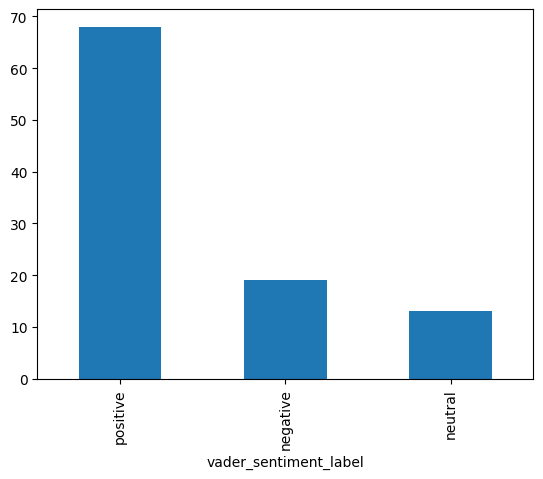

In [13]:
data['vader_sentiment_label'].value_counts().plot.bar()

In [ ]:
transformer_pipeline = pipeline("sentiment-analysis")


In [ ]:
transformers_labels = []

for review in data['reviewText_clean'].values:

    sentiment_list = transformer_pipeline(review)

    sentiment_label = [sent['label'] for sent in sentiment_list]

    transformers_labels.append(sentiment_label) 

data['transformers_sentiment_label'] = transformers_labels

NameError: name 'transformer_pipeline' is not defined